<a href="https://colab.research.google.com/github/Tuna10001/Assignments-on-remote-sensing-and-water-quality-data-analysis/blob/main/Hydrochemical%20analysis%20assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install if necessary
# !pip install pandas openpyxl matplotlib

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a pandas DataFrame
df = pd.read_excel("/content/")  # Changed this line

# Display the DataFrame (optional, for checking)
display(df) # Changed this line

,Code_1,Type_3,Feature,Lat,Long,Elevation(masl),Temp (°C),pH (-),EC (µS/cm),"δ18O, in ‰",...,Sr \n(mg/L),Al\n(mg/L),Mn \n(mg/L),Fe \n(mg/L),Geology_1,Geology_2,Geology_3,Source_area_?,COMMENTS,Comments on chemistry
0,WP07,RF,Waterpan,-1.181956,35.734114,1856,20.9,7.540,225.0,2.59,...,0.084872,2.872217,0.110049,2.218853,Qv,Quaternary,Volcanic soils derived from ashes,Quaternary-Volcanic,Used for livestock; highly turbid; materials d...,NaN
1,WP08,RF,Waterpan,-1.217033,35.718057,1861,21.6,7.500,99.9,1.22,...,0.088773,2.752602,0.148989,2.710795,Qv,Quaternary,Volcanic soils derived from ashes,Quaternary-Volcanic,"Turbid, surface runoff fed; materiald dug out ...",To check in second season
2,WP11,GF,Waterpan,-1.416279,35.454890,1756,23.4,9.450,227.0,-1.83,...,0.125906,0.136838,0.003077,0.027949,Qr,Quaternary,Black soils overlying basement system,Archaen-Quartzites,Presence of wild animals (Hippo); fed by sprin...,To check in second season
3,WP12,RF,Waterpan,-1.313734,35.621488,1895,21.6,8.130,177.0,1.72,...,0.063520,3.128271,0.057713,1.686066,Qv,Quaternary,Volcanic soils derived from ashes,Quaternary-Volcanic,"Marshy area, Constructed by World bank, used f...",To check in second season
4,WP09,RF,Waterpan,-1.229306,35.705666,1860,20.6,7.177,194.0,2.27,...,0.092312,3.274806,0.120800,2.881630,Qv,Quaternary,Volcanic soils derived from ashes,Quaternary-Volcanic,Used for livestock; turbid,To check in second season
5,SP02,GF,Spring,-1.337000,35.710280,1930,48.7,7.120,535.0,-5.63,...,0.095335,0.189069,0.061660,0.109357,Qr,Quaternary,Red sandy soils,Archaen-Quartzites,Geothermal origin; hot water,NaN
6,WP14,GF,Waterpan,-1.336842,35.710203,1930,24.7,9.420,321.0,-3.95,...,0.125145,0.289349,0.019247,0.218477,Qr,Quaternary,Red sandy soils,Archaen-Quartzites,Waterpan from,To check in second season
7,WP15,GF,Waterpan,-1.241639,35.680698,1859,22.8,8.600,1941.0,-1.00,...,1.216225,0.044208,0.017281,0.002000,Qv,Quaternary,Volcanic soils derived from ashes,Archaen-Quartzites,Marshy wetland area,NaN
8,WP01,RF,Waterpan,-0.978144,35.526829,2005,20.5,7.266,181.8,3.83,...,0.078786,2.399252,0.043595,1.238944,Qv,Quaternary,Volcanic soils derived from ashes,Quaternary-Volcanic,"Olerai area, from road construction; used for ...",To check in second season
9,WP02,RF,Waterpan,-0.989390,35.580602,2039,18.6,7.328,29.6,4.34,...,0.061938,2.834321,0.024278,2.060012,Qv,Quaternary,Volcanic soils derived from ashes,Quaternary-Volcanic,Turbid; used for livestock and irrigation,To check in second season


In [ ]:
# First, clean the column names (remove spaces, line breaks)
df.columns = df.columns.str.strip().str.replace('\n', ' ').str.replace('  ', ' ')

# Then, rename specific important columns for easy access
df = df.rename(columns={
    'Na (mg/L)': 'Na',
    'K (mg/L)': 'K',
    'Ca (mg/L)': 'Ca',
    'Mg (mg/L)': 'Mg',
    'Cl': 'Cl',
    'SO4': 'SO4',
    'HCO3 (Mg/l)': 'HCO3',
    'NO3': 'NO3',
    'Br': 'Br',
    'Alkalinity as CaCO3 (mg/L)': 'Alkalinity',
    'EC (µS/cm)': 'EC',
})

# Create TDS (mg/L) approximation from EC
df['TDS'] = 0.64 * df['EC']

# Show cleaned columns
print("✅ Columns cleaned and renamed. Available columns now:")
print(df.columns.tolist())


✅ Columns cleaned and renamed. Available columns now:
['Code_1', 'Type_3', 'Feature', 'Lat', 'Long', 'Elevation(masl)', 'Temp (°C)', 'pH (-)', 'EC', 'δ18O, in ‰', 'δ2H, in ‰', 'D-excess', 'F', 'Cl', 'NO3', 'SO4', 'HCO3', 'Br', 'NO2', 'P', 'O2', 'Na', 'K', 'Ca', 'Mg', 'Sr (mg/L)', 'Al (mg/L)', 'Mn (mg/L)', 'Fe (mg/L)', 'Geology_1', 'Geology_2', 'Geology_3', 'Source_area_?', 'COMMENTS', 'Comments on chemistry', 'TDS']


In [ ]:
!pip install adjustText

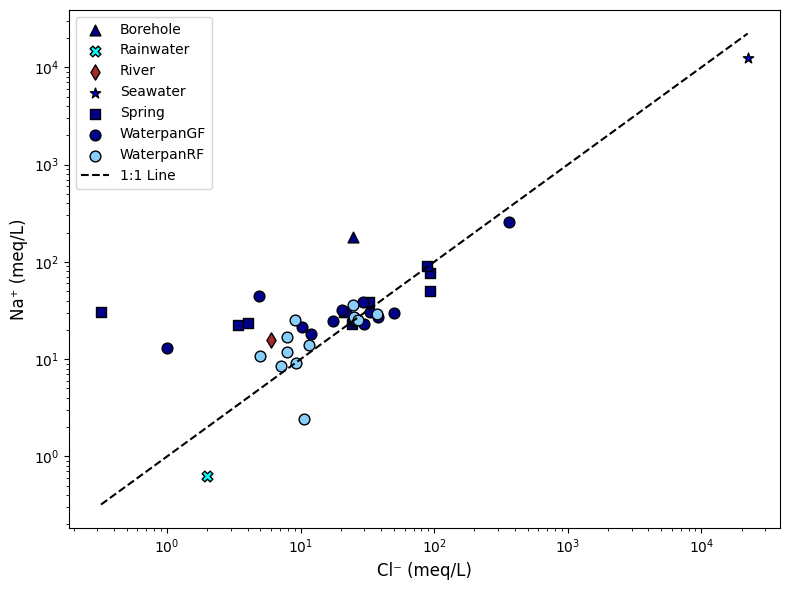

In [ ]:
# First, set up grouping manually using Feature and Type_3
def classify_sample(row):
    code = row['Code_1']
    feature = row['Feature']
    typ = row['Type_3']

    if 'SEA' in code:
        return 'Seawater'
    elif 'RW' in code:
        return 'Rainwater'
    else:
        if 'Waterpan' in feature and 'RF' in typ:
            return 'WaterpanRF'
        elif 'Waterpan' in feature and 'GF' in typ:
            return 'WaterpanGF'
        elif 'Spring' in feature:
            return 'Spring'
        elif 'Borehole' in feature:
            return 'Borehole'
        else:
            return 'River'

# Create a new column for sample type
df['Sample_Type'] = df.apply(classify_sample, axis=1)

# Define colors for each group
colors = {
    'WaterpanRF': 'lightskyblue',
    'WaterpanGF': 'darkblue',
    'Spring': 'darkblue',
    'Borehole': 'darkblue',
    'Rainwater': 'cyan',
    'Seawater': 'blue',
    'River': 'brown'
}

# Define markers for each group
markers = {
    'WaterpanRF': 'o',  # circle
    'WaterpanGF': 'o',  # circle
    'Spring': 's',      # square
    'Borehole': '^',    # triangle
    'Rainwater': 'X',   # X
    'Seawater': '*',    # star
    'River': 'd'        # diamond
}

# Plot Na vs Cl on log-log scale
plt.figure(figsize=(8,6))

for sample_type, group_data in df.groupby('Sample_Type'):
    plt.scatter(group_data['Cl'], group_data['Na'],
                label=sample_type,
                c=colors.get(sample_type, 'grey'),
                marker=markers.get(sample_type, 'o'),
                edgecolors='black',
                s=60)

# Add 1:1 reference line
min_val = min(df['Cl'].min(), df['Na'].min())
max_val = max(df['Cl'].max(), df['Na'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Log scale
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Cl⁻ (meq/L)', fontsize=12)
plt.ylabel('Na⁺ (meq/L)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()




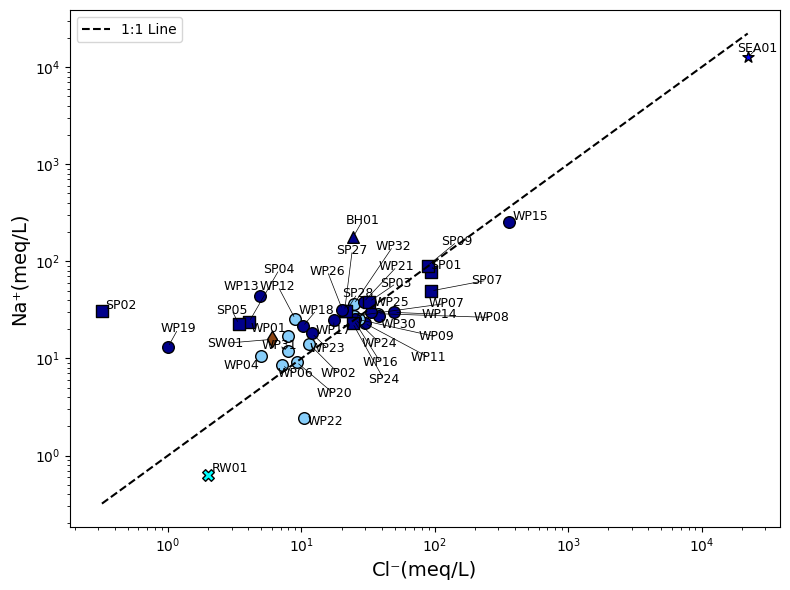

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text # Import the adjustText library

# Assuming your DataFrame 'df' is already created as in your original code

# First, set up grouping manually using Feature and Type_3
def classify_sample(row):
    code = row['Code_1']
    feature = row['Feature']
    typ = row['Type_3']

    if 'SEA' in code:
        return 'Seawater'
    elif 'RW' in code:
        return 'Rainwater'
    else:
        if 'Waterpan' in feature and 'RF' in typ:
            return 'WaterpanRF'
        elif 'Waterpan' in feature and 'GF' in typ:
            return 'WaterpanGF'
        elif 'Spring' in feature:
            return 'Spring'
        elif 'Borehole' in feature:
            return 'Borehole'
        else:
            return 'River'

# Create a new column for sample type
df['Sample_Type'] = df.apply(classify_sample, axis=1)

# Define colors for each group
colors = {
    'WaterpanRF': 'lightskyblue',
    'WaterpanGF': 'darkblue',
    'Spring': 'darkblue',
    'Borehole': 'darkblue',
    'Rainwater': 'cyan',
    'Seawater': 'blue',
    'River': 'saddlebrown'
}

# Define markers for each group
markers = {
    'WaterpanRF': 'o',   # circle
    'WaterpanGF': 'o',   # circle
    'Spring': 's',       # square
    'Borehole': '^',     # triangle
    'Rainwater': 'X',    # X
    'Seawater': '*',     # star
    'River': 'd'         # diamond
}

# Plot Na vs Cl on log-log scale
plt.figure(figsize=(8, 6)) # Increased figure size

texts = [] # Store text objects for adjustment

for index, row in df.iterrows():
    plt.scatter(row['Cl'], row['Na'],
                c=colors.get(row['Sample_Type'], 'grey'),
                marker=markers.get(row['Sample_Type'], 'o'),
                edgecolors='black',
                s=70)
    texts.append(plt.text(row['Cl'], row['Na'], row['Code_1'], fontsize=9)) # Add text label

# Add 1:1 reference line
min_val = min(df['Cl'].min(), df['Na'].min())
max_val = max(df['Cl'].max(), df['Na'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Log scale
plt.xscale('log')
plt.yscale('log')

# Improved labels and title
plt.xlabel('Cl⁻(meq/L)', fontsize=14)
plt.ylabel('Na⁺(meq/L)', fontsize=14)
plt.grid(False)

# Adjust text labels to minimize overlap
adjust_text(texts,
            arrowprops=dict(arrowstyle='-', color='black', lw=0.5),
            autoalign='xy',
            expand_points=(2, 2),
            force_points=(0.2, 0.2))

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

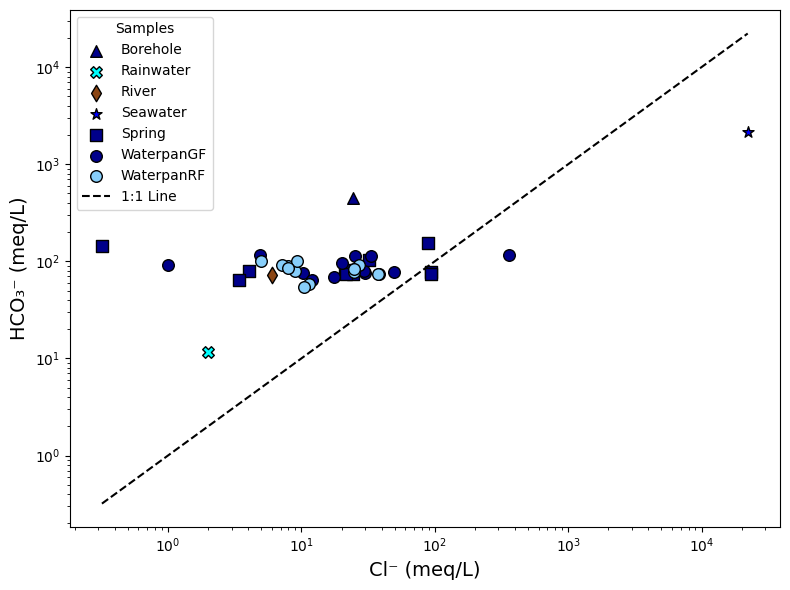

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text

# Assuming df already created and contains 'Code_1', 'Cl', 'HCO3', etc.

# Classify Sample Type
def classify_sample(row):
    code = row['Code_1']
    feature = row['Feature']
    typ = row['Type_3']

    if 'SEA' in code:
        return 'Seawater'
    elif 'RW' in code:
        return 'Rainwater'
    else:
        if 'Waterpan' in feature and 'RF' in typ:
            return 'WaterpanRF'
        elif 'Waterpan' in feature and 'GF' in typ:
            return 'WaterpanGF'
        elif 'Spring' in feature:
            return 'Spring'
        elif 'Borehole' in feature:
            return 'Borehole'
        else:
            return 'River'

# Add Sample_Type column
df['Sample_Type'] = df.apply(classify_sample, axis=1)

# Define colors and markers
colors = {
    'WaterpanRF': 'lightskyblue',
    'WaterpanGF': 'darkblue',
    'Spring': 'darkblue',
    'Borehole': 'darkblue',
    'Rainwater': 'cyan',
    'Seawater': 'blue',
    'River': 'saddlebrown'
}

markers = {
    'WaterpanRF': 'o',
    'WaterpanGF': 'o',
    'Spring': 's',
    'Borehole': '^',
    'Rainwater': 'X',
    'Seawater': '*',
    'River': 'd'
}

# --- Plotting starts here ---
plt.figure(figsize=(8, 6))

texts = []

# Grouped plotting by Sample_Type (this fixes the legend!)
for sample_type, group_data in df.groupby('Sample_Type'):
    plt.scatter(group_data['Cl'], group_data['HCO3'],
                c=colors.get(sample_type, 'grey'),
                marker=markers.get(sample_type, 'o'),
                edgecolors='black',
                s=70,
                label=sample_type)  # <-- Here: Label for legend

# Add 1:1 reference line
min_val = min(df['Cl'].min(), df['HCO3'].min())
max_val = max(df['Cl'].max(), df['HCO3'].max())
min_val = max(min_val, 0.01)

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Log scales
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Cl⁻ (meq/L)', fontsize=14)
plt.ylabel('HCO₃⁻ (meq/L)', fontsize=14)

# No grid
plt.grid(False)

# Legend
plt.legend(fontsize=10, title='Samples')
plt.tight_layout()
plt.show()


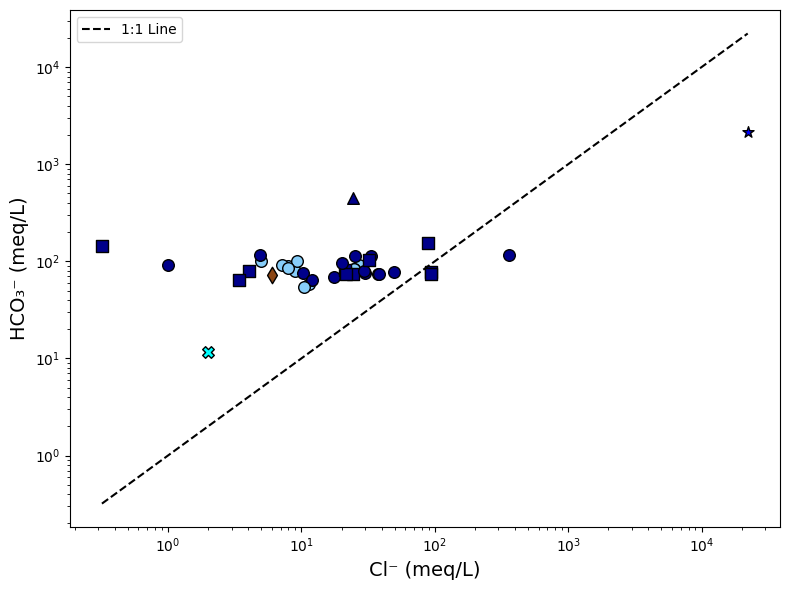

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from adjustText import adjust_text

# Assuming df already created and contains 'Code_1', 'Cl', 'HCO3', etc.

# Classify Sample Type
def classify_sample(row):
    code = row['Code_1']
    feature = row['Feature']
    typ = row['Type_3']

    if 'SEA' in code:
        return 'Seawater'
    elif 'RW' in code:
        return 'Rainwater'
    else:
        if 'Waterpan' in feature and 'RF' in typ:
            return 'WaterpanRF'
        elif 'Waterpan' in feature and 'GF' in typ:
            return 'WaterpanGF'
        elif 'Spring' in feature:
            return 'Spring'
        elif 'Borehole' in feature:
            return 'Borehole'
        else:
            return 'River'

# Add Sample_Type column
df['Sample_Type'] = df.apply(classify_sample, axis=1)

# Define colors and markers
colors = {
    'WaterpanRF': 'lightskyblue',
    'WaterpanGF': 'darkblue',
    'Spring': 'darkblue',
    'Borehole': 'darkblue',
    'Rainwater': 'cyan',
    'Seawater': 'blue',
    'River': 'saddlebrown'
}

markers = {
    'WaterpanRF': 'o',
    'WaterpanGF': 'o',
    'Spring': 's',
    'Borehole': '^',
    'Rainwater': 'X',
    'Seawater': '*',
    'River': 'd'
}

# --- Now plot HCO3 vs Cl (instead of Na vs Cl) ---

plt.figure(figsize=(8, 6))  # Good size


# Scatter points with labels
for index, row in df.iterrows():
    plt.scatter(row['Cl'], row['HCO3'],
                c=colors.get(row['Sample_Type'], 'grey'),
                marker=markers.get(row['Sample_Type'], 'o'),
                edgecolors='black',
                s=70)

# Add 1:1 reference line
# --- Important: fix minimum value for log scale ---
min_val = min(df['Cl'].min(), df['HCO3'].min())
max_val = max(df['Cl'].max(), df['HCO3'].max())
min_val = max(min_val, 0.01)  # Cannot plot 0 on log scale

plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Log-log scale
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.xlabel('Cl⁻ (meq/L)', fontsize=14)
plt.ylabel('HCO₃⁻ (meq/L)', fontsize=14)

# No grid (your style)
plt.grid(False)


# Legend
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
selected_types = ['Seawater', 'Rainwater']
filtered_df = df[df['Sample_Type'].isin(selected_types)]

print("Filtered sample count:")
print(filtered_df['Sample_Type'].value_counts())

# Also check if there are NaN values
print("Missing values check:")
print(filtered_df[['Cl', 'HCO3']].isna().sum())


Filtered sample count:
Sample_Type
Rainwater    1
Seawater     1
Name: count, dtype: int64
Missing values check:
Cl      0
HCO3    0
dtype: int64


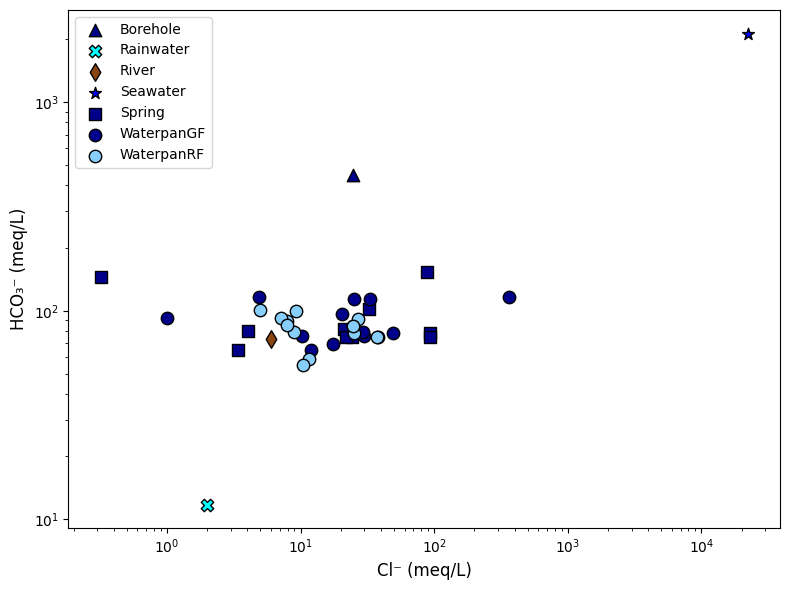

In [ ]:
# Plot HCO3 vs Cl on log-log scale (in meq/L)

# Fig size
plt.figure(figsize=(8, 6)) # Increased figure size

for sample_type, group_data in df.groupby('Sample_Type'):
    plt.scatter(group_data['Cl'], group_data['HCO3'],
                label=sample_type,
                c=colors.get(sample_type, 'grey'),
                marker=markers.get(sample_type, 'o'),
                edgecolors='black',
                s=80)

# Log-log scale
plt.xscale('log')
plt.yscale('log')


plt.xlabel('Cl⁻ (meq/L)', fontsize=12)
plt.ylabel('HCO₃⁻ (meq/L)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()



In [ ]:
import numpy as np

# Calculate log Ksp based on temperature for each sample
df['log_Ksp_Calcite'] = -171.9065 - 0.077993 * df['Temp (°C)'] + (2839.319 / (df['Temp (°C)'] + 273.15)) + 71.595

# Convert to Ksp (not log Ksp)
df['Ksp_Calcite'] = 10**(df['log_Ksp_Calcite'])

# Step 1: Convert Ca and HCO3 from mg/L to mol/L
df['Ca'] = df['Ca'] / 40.08 / 1000
df['HCO3'] = df['HCO3'] / 61.02 / 1000

# Step 2: Calculate CO3 mol/L from HCO3 and pH
pK2 = 10.3  # at 25°C, good approximation unless you want temperature-corrected pK2 too
df['CO3'] = df['HCO3'] / (10**(pK2 - df['pH (-)']))

# Step 3: Calculate IAP (Ionic Activity Product)
df['IAP'] = df['Ca'] * df['CO3']

# Step 4: Calculate Saturation Index (SI) for Calcite (with individual Ksp)
df['SI_Calcite'] = np.log10(df['IAP'] / df['Ksp_Calcite'])


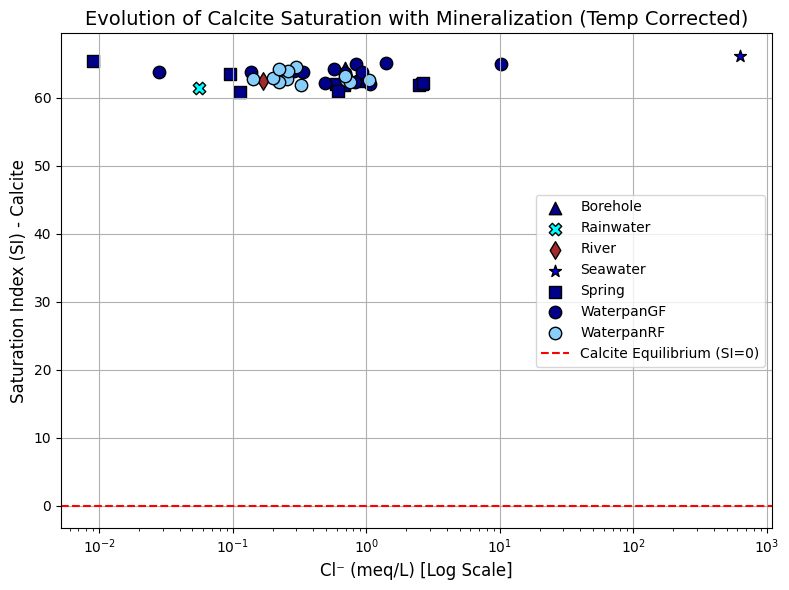

In [ ]:
# Plot SI(Calcite) vs Cl in meq/L and log x-axis

plt.figure(figsize=(8,6))


for sample_type, group_data in df.groupby('Sample_Type'):
    plt.scatter(group_data['Cl'], group_data['SI_Calcite'],
                label=sample_type,
                c=colors.get(sample_type, 'grey'),
                marker=markers.get(sample_type, 'o'),
                edgecolors='black',
                s=80)

# Add SI=0 equilibrium line
plt.axhline(y=0, color='red', linestyle='--', label='Calcite Equilibrium (SI=0)')

# X-axis log scale
plt.xscale('log')

plt.xlabel('Cl⁻ (meq/L) [Log Scale]', fontsize=12)
plt.ylabel('Saturation Index (SI) - Calcite', fontsize=12)
plt.title('Evolution of Calcite Saturation with Mineralization (Temp Corrected)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Function to convert mg/L to meq/L
def mgL_to_meqL(mgL, molar_mass, valence):
    return (mgL / molar_mass) * valence

# Molar masses (g/mol) and valences
molar_masses = {'Ca': 40.08, 'Mg': 24.305, 'SO4': 96.06, 'HCO3': 61.02}
valences = {'Ca': 2, 'Mg': 2, 'SO4': 2, 'HCO3': 1}

# Convert each ion
df['Ca_meqL'] = mgL_to_meqL(df['Ca'], molar_masses['Ca'], valences['Ca'])
df['Mg_meqL'] = mgL_to_meqL(df['Mg'], molar_masses['Mg'], valences['Mg'])
df['SO4_meqL'] = mgL_to_meqL(df['SO4'], molar_masses['SO4'], valences['SO4'])
df['HCO3_meqL'] = mgL_to_meqL(df['HCO3'], molar_masses['HCO3'], valences['HCO3'])


In [ ]:
# Add Cations and Anions
df['Cations_CaMg_meqL'] = df['Ca_meqL'] + df['Mg_meqL']
df['Anions_SO4HCO3_meqL'] = df['SO4_meqL'] + df['HCO3_meqL']


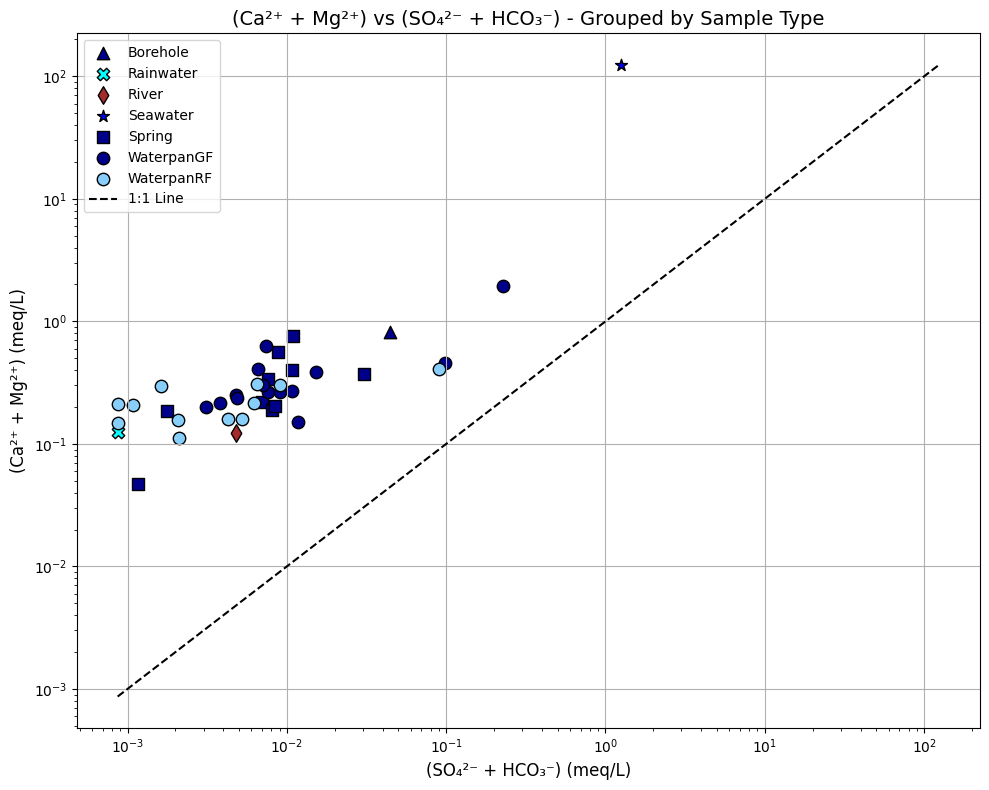

In [ ]:
# Plotting (log-log scale)
plt.figure(figsize=(10,8))



for sample_type, group_data in df.groupby('Sample_Type'):
    plt.scatter(group_data['Anions_SO4HCO3_meqL'], group_data['Cations_CaMg_meqL'],
                label=sample_type,
                c=colors.get(sample_type, 'grey'),
                marker=markers.get(sample_type, 'o'),
                edgecolors='black',
                s=80)

# 1:1 line
min_val = min(df['Anions_SO4HCO3_meqL'].min(), df['Cations_CaMg_meqL'].min())
max_val = max(df['Anions_SO4HCO3_meqL'].max(), df['Cations_CaMg_meqL'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')

# Set log scales
plt.xscale('log')
plt.yscale('log')

plt.xlabel('(SO₄²⁻ + HCO₃⁻) (meq/L)', fontsize=12)
plt.ylabel('(Ca²⁺ + Mg²⁺) (meq/L)', fontsize=12)
plt.title('(Ca²⁺ + Mg²⁺) vs (SO₄²⁻ + HCO₃⁻) - Grouped by Sample Type', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()



In [ ]:
import plotly.express as px

# Prepare a temporary plotting DataFrame
df_plot = df.copy()

# Create the plot
fig = px.scatter(
    df_plot,
    x='Anions_SO4HCO3_meqL',
    y='Cations_CaMg_meqL',
    color='Sample_Type',       # Color by type (Rainwater, WaterpanRF, etc.)
    hover_data=['Code_1', 'Feature', 'Type_3', 'Cl', 'Na', 'HCO3', 'SO4'],  # Info to display when you hover
    labels={
        'Anions_SO4HCO3_meqL': '(SO₄²⁻ + HCO₃⁻) (meq/L)',
        'Cations_CaMg_meqL': '(Ca²⁺ + Mg²⁺) (meq/L)'
    },
    title='Interactive Plot: (Ca²⁺ + Mg²⁺) vs (SO₄²⁻ + HCO₃⁻)'
)

# Add 1:1 line manually
fig.add_shape(
    type="line",
    x0=df_plot['Anions_SO4HCO3_meqL'].min(),
    y0=df_plot['Anions_SO4HCO3_meqL'].min(),
    x1=df_plot['Anions_SO4HCO3_meqL'].max(),
    y1=df_plot['Anions_SO4HCO3_meqL'].max(),
    line=dict(color="black", dash="dash"),
    name='1:1 Line'
)

# Log scales
fig.update_xaxes(type="log")
fig.update_yaxes(type="log")

fig.update_layout(
    width=900,
    height=700,
    legend_title_text='Sample Type',
    hoverlabel=dict(bgcolor="white", font_size=12)
)

fig.show()


In [ ]:
# Conversion function
def to_meqL(value, molar_mass, valence):
    return (value / molar_mass) * valence

# Molar masses (g/mol) and valences
molar_masses = {
    'Cl': 35.45,
    'Na': 22.99,
    'K': 39.10,
    'SO4': 96.06,
    'HCO3': 61.02,
    'NO3': 62.00
}

valences = {
    'Cl': 1,
    'Na': 1,
    'K': 1,
    'SO4': 2,
    'HCO3': 1,
    'NO3': 1
}

# Now apply conversion for each ion
df['Cl_meqL'] = to_meqL(df['Cl'], molar_masses['Cl'], valences['Cl'])
df['Na_meqL'] = to_meqL(df['Na'], molar_masses['Na'], valences['Na'])
df['K_meqL'] = to_meqL(df['K'], molar_masses['K'], valences['K'])
df['SO4_meqL'] = to_meqL(df['SO4'], molar_masses['SO4'], valences['SO4'])
df['HCO3_meqL'] = to_meqL(df['HCO3'], molar_masses['HCO3'], valences['HCO3'])
df['NO3_meqL'] = to_meqL(df['NO3'], molar_masses['NO3'], valences['NO3'])



In [ ]:
# Now calculate CAI-I and CAI-II
df['CAI_I'] = (df['Cl_meqL'] - (df['Na_meqL'] + df['K_meqL'])) / df['Cl_meqL']

df['CAI_II'] = (df['Cl_meqL'] - (df['Na_meqL'] + df['K_meqL'])) / (
    df['SO4_meqL'] + df['HCO3_meqL'] + df['NO3_meqL']
)


In [ ]:
# Show only the important CAI results
print(df[['Code_1', 'Feature', 'Sample_Type', 'CAI_I', 'CAI_II']])


   Code_1   Feature Sample_Type       CAI_I     CAI_II
0    WP07  Waterpan  WaterpanRF   -2.203741  -4.804404
1    WP08  Waterpan  WaterpanRF   -1.262225  -5.769018
2    WP11  Waterpan  WaterpanGF   -1.123980  -5.554826
3    WP12  Waterpan  WaterpanRF   -7.184189 -24.431445
4    WP09  Waterpan  WaterpanRF   -1.778629 -22.959370
5    SP02    Spring      Spring -261.634578  -7.567552
6    WP14  Waterpan  WaterpanGF   -0.637652  -3.377576
7    WP15  Waterpan  WaterpanGF   -0.878101  -1.116481
8    WP01  Waterpan  WaterpanRF   -6.006760 -34.504038
9    WP02  Waterpan  WaterpanRF   -2.924348  -5.080574
10   WP04  Waterpan  WaterpanRF   -6.827840 -31.198125
11   WP06  Waterpan  WaterpanRF   -3.884058 -10.582521
12   WP13  Waterpan  WaterpanGF  -21.714053  -7.214032
13   SP01    Spring      Spring   -1.147796  -2.770364
14   WP17  Waterpan  WaterpanGF   -2.731797  -9.900131
15   SP04    Spring      Spring  -13.804325 -24.980292
16   WP18  Waterpan  WaterpanGF   -4.520467 -11.668944
17   SP05 

In [ ]:
import plotly.express as px

# Prepare plotting DataFrame
df_plot = df.copy()

# Create CAI scatter plot
fig = px.scatter(
    df_plot,
    x='CAI_I',
    y='CAI_II',
    color='Sample_Type',    # Group by Sample Type
    symbol='Feature',       # Different shapes for Waterpan, Borehole, etc.
    hover_data=['Code_1', 'Feature', 'Type_3'],  # Info on hover
    labels={
        'CAI_I': 'Chloro-Alkaline Index I',
        'CAI_II': 'Chloro-Alkaline Index II'
    },
    title='Chloro-Alkaline Indices (CAI-I vs CAI-II)'
)

# Add reference lines at x=0 and y=0
fig.add_shape(type="line", x0=0, y0=df_plot['CAI_II'].min(), x1=0, y1=df_plot['CAI_II'].max(),
              line=dict(color="black", dash="dash"))
fig.add_shape(type="line", x0=df_plot['CAI_I'].min(), y0=0, x1=df_plot['CAI_I'].max(), y1=0,
              line=dict(color="black", dash="dash"))

fig.update_layout(
    width=900,
    height=700,
    legend_title_text='Sample Type',
    hoverlabel=dict(bgcolor="white", font_size=12),
    xaxis=dict(zeroline=False),
    yaxis=dict(zeroline=False)
)

fig.show()
